In [1]:
%load_ext autoreload
%autoreload 2

import base64
from dataclasses import dataclass
import html
import io
from pathlib import Path
import urllib.request

import PIL.Image
import transformers
import torch
from torch import nn, Tensor
import safetensors.torch

import weight_formats.quantisation as Q
import weight_formats.quantisation_training as QT

import vqa_interactive as V

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [2]:
vqa = V.LlamaVQA()

Loading checkpoint shards:   0%|          | 0/5 [00:00<?, ?it/s]

In [ ]:
fmt = Q.LinearScalingFormat(
    Q.parse("E0M2"),
    scale_format=Q.BFLOAT16,
    block_shape=(1, 128),
    scaling="absmax",
)
vqa.load_model("dc", "vital-salad-920", fmt)
vqa.load_model("qat", "laced-music-918", fmt)

In [5]:
vqa.load_image("rabbit", "https://huggingface.co/datasets/huggingface/documentation-images/resolve/0052a70beed5bf71b92610a43a52df6d286cd5f3/diffusers/rabbit.jpg")
vqa.load_image("wolfhound", "https://github.com/EliSchwartz/imagenet-sample-images/blob/master/n02090721_Irish_wolfhound.JPEG?raw=true")
vqa.load_image("graphcore", "https://graphcore-research.github.io/assets/images/posts/2024-12/llama-vision/image.png")

  0%|          | 0/6 [00:00<?, ?it/s]

100%|██████████| 6/6 [00:21<00:00,  3.58s/it]


Completions(image=<PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=2048x2688 at 0x7BB1DDBC4920>, prompt="What is the rabbit's name?", completions={'base[instruct]': 'The rabbit in the image is likely Peter Rabbit, a character created by Beatrix Potter.<|eot_id|>', 'base[simple]': ' The rabbit\'s name is Peter Rabbit. He is a fictional character created by Beatrix Potter and is the main character in her children\'s book "The Tale of Peter Rabbit." Peter Rabbit is a mis', 'dc[instruct]': 'The rabbit\'s name is "Flozagel". This name is not a typo or mispronunciation of the rabbit\'s name from the book "The Rabbit\'s Rabbit" which the rabbit\'s character is', 'dc[simple]': " I'm not able to read the text in the image. I'm just an AI. Please provide your name. \n\nThe rabbit's name is Peter Rabbit. However, I'm not able to read", 'qat[instruct]': "The rabbit's name is Peter.<|eot_id|>", 'qat[simple]': ' The rabbit\'s name is Peter. He is a character from the book "The Tale of Peter Rabbit" by Beatrix Potter. The book was published in 1902 and has since become a beloved'})
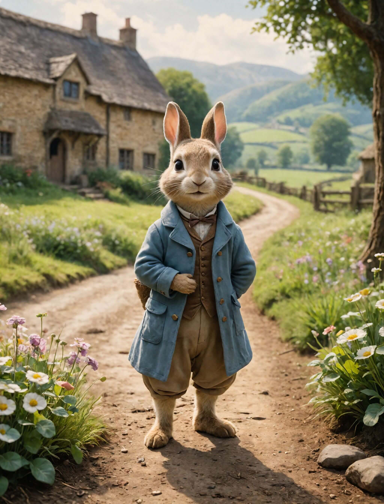

In [6]:
vqa("rabbit", "What is the rabbit's name?",
    ("base", "instruct"),
    ("base", "simple"),
    ("dc", "instruct"),
    ("dc", "simple"),
    ("qat", "instruct"),
    ("qat", "simple"),
)

  0%|          | 0/6 [00:00<?, ?it/s]

100%|██████████| 6/6 [00:21<00:00,  3.54s/it]


Completions(image=<PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=250x206 at 0x7BB1DDBCBF80>, prompt='Describe the image:\n', completions={'base[instruct]': 'The image features a close-up of an Irish Wolfhound lying on a blanket, with the dog occupying approximately 75% of the frame. The dog is positioned on the right side of the image,', 'base[simple]': 'The image is a close-up photograph of a dog lying on a blanket. The dog is mostly in the frame, and is looking off to the left side of the image. The dog is grey,', 'dc[instruct]': 'The image shows a dog lying next to a wolfhound.<|eot_id|>', 'dc[simple]': "The image depicts two dogs lying next to each other on top of a blanket. They are both medium/light grey colour dogs covered in fluffy fur that is longer than the dogs' bodies. They appear to", 'qat[instruct]': 'The image depicts a large, shaggy grey dog lying down on a red, black, and yellow plaid blanket. The dog appears to be an Irish Wolfhound, with its thick fur and', 'qat[simple]': 'The image shows a close-up of an Irish Wolfhound lying down on a plaid blanket. The dog is mostly gray with some brown and black patches on its back. Its fur is long and unk'})
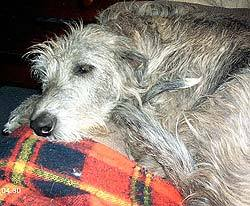

In [14]:
vqa("wolfhound", "Describe the image:\n",
    ("base", "instruct"),
    ("base", "simple"),
    ("dc", "instruct"),
    ("dc", "simple"),
    ("qat", "instruct"),
    ("qat", "simple"),
    do_sample=True
)

  0%|          | 0/6 [00:00<?, ?it/s]

100%|██████████| 6/6 [00:19<00:00,  3.23s/it]


Completions(image=<PIL.PngImagePlugin.PngImageFile image mode=RGBA size=515x299 at 0x7BB1DDBD1B80>, prompt='What colour shirt is the person to the left of the laptop wearing?', completions={'base[instruct]': 'The person to the left of the laptop is wearing a red shirt.<|eot_id|>', 'base[simple]': ' The person to the left of the laptop is wearing a red shirt. The person to the left of the laptop is wearing a red shirt. The person to the left of the laptop is wearing a red', 'dc[instruct]': 'The colour shirt worn by the person to the left of the laptop is teal-blue-ish colour shirt worn$LANGRuntimeObject_erroršti$LANG<|eot_id|>', 'dc[simple]': ' \n\nThe image is too blurry to determine the colour of the shirt worn by the person to the left of the laptop.\n\nHowever we can determine the colour of the shirt worn by the person to the left', 'qat[instruct]': 'The person to the left of the laptop is wearing a blue shirt.<|eot_id|>', 'qat[simple]': ' The person to the left of the laptop is wearing a blue shirt. The person to the left of the blue shirt is wearing a red shirt. The person to the left of the red shirt is wearing'})
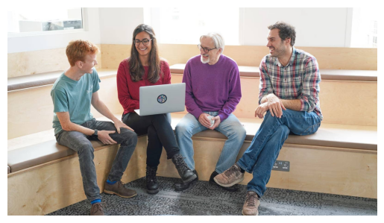

In [15]:
vqa("graphcore", "What colour shirt is the person to the left of the laptop wearing?",
    ("base", "instruct"),
    ("base", "simple"),
    ("dc", "instruct"),
    ("dc", "simple"),
    ("qat", "instruct"),
    ("qat", "simple"),
)